In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve, f1_score,
                              precision_score, recall_score, accuracy_score)

In [5]:
import pandas as pd

# Load all 5 sheets
xls = pd.ExcelFile('Customer_Churn_Data_Large.xlsx')

demo   = xls.parse('Customer_Demographics')
txn    = xls.parse('Transaction_History')
cs     = xls.parse('Customer_Service')
online = xls.parse('Online_Activity')
churn  = xls.parse('Churn_Status')

print("All sheets loaded!")

All sheets loaded!


In [6]:
# Aggregate transactions per customer
txn_agg = txn.groupby('CustomerID').agg(
    TotalSpent       = ('AmountSpent', 'sum'),
    AvgSpent         = ('AmountSpent', 'mean'),
    TransactionCount = ('TransactionID', 'count')
).reset_index()

# Aggregate customer service per customer
cs_agg = cs.groupby('CustomerID').agg(
    TotalInteractions = ('InteractionID', 'count'),
    ComplaintCount    = ('InteractionType', lambda x: (x=='Complaint').sum()),
    UnresolvedCount   = ('ResolutionStatus', lambda x: (x=='Unresolved').sum())
).reset_index()
cs_agg['UnresolvedRate'] = cs_agg['UnresolvedCount'] / cs_agg['TotalInteractions']

# Days since last login
online['LastLoginDate'] = pd.to_datetime(online['LastLoginDate'])
ref_date = online['LastLoginDate'].max()
online['DaysSinceLogin'] = (ref_date - online['LastLoginDate']).dt.days

# Merge all together
df = demo.merge(churn, on='CustomerID', how='left')
df = df.merge(txn_agg, on='CustomerID', how='left')
df = df.merge(cs_agg, on='CustomerID', how='left')
df = df.merge(online[['CustomerID','LoginFrequency','ServiceUsage','DaysSinceLogin']],
              on='CustomerID', how='left')

# Fill zeros for missing aggregated values
fill_cols = ['TotalSpent','AvgSpent','TransactionCount',
             'TotalInteractions','ComplaintCount','UnresolvedCount','UnresolvedRate']
df[fill_cols] = df[fill_cols].fillna(0)

print("Merged shape:", df.shape)
print("Churn rate:", df['ChurnStatus'].mean().round(4))

Merged shape: (1000, 16)
Churn rate: 0.204


In [7]:
from sklearn.preprocessing import StandardScaler

# Encode categorical variables
df['Gender_enc']      = (df['Gender'] == 'M').astype(int)
df['IncomeLevel_enc'] = df['IncomeLevel'].map({'Low':0, 'Medium':1, 'High':2})
df = pd.get_dummies(df, columns=['MaritalStatus','ServiceUsage'])

# Drop original/ID columns
df_model = df.drop(columns=['CustomerID','Gender','IncomeLevel','LastLoginDate'], errors='ignore')

# Scale numeric features
num_cols = ['Age','TotalSpent','AvgSpent','TransactionCount','TotalInteractions',
            'ComplaintCount','UnresolvedCount','UnresolvedRate','LoginFrequency','DaysSinceLogin']
scaler = StandardScaler()
df_model[num_cols] = scaler.fit_transform(df_model[num_cols])

# Prepare X and y
X = df_model.drop(columns=['ChurnStatus'])
y = df_model['ChurnStatus']

# Convert bool columns
bool_cols = X.select_dtypes('bool').columns
X[bool_cols] = X[bool_cols].astype(int)

print("Final X shape:", X.shape)
print("Target:\n", y.value_counts())

Final X shape: (1000, 19)
Target:
 ChurnStatus
0    796
1    204
Name: count, dtype: int64


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

Training set: (800, 19)
Test set: (200, 19)


In [9]:
model = LogisticRegression(
    class_weight='balanced',  # handles imbalance
    max_iter=1000,
    random_state=42
)
model.fit(X_train, y_train)
print("Model trained successfully!")

Model trained successfully!


In [10]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = cross_validate(model, X, y, cv=cv,
    scoring=['accuracy', 'roc_auc', 'f1', 'precision', 'recall'])

print("===== 5-Fold Cross-Validation Results =====")
for metric in ['accuracy', 'roc_auc', 'f1', 'precision', 'recall']:
    scores = cv_results[f'test_{metric}']
    print(f"{metric:12}: {scores.mean():.4f} ± {scores.std():.4f}")

===== 5-Fold Cross-Validation Results =====
accuracy    : 0.5500 ± 0.0305
roc_auc     : 0.5363 ± 0.0197
f1          : 0.3005 ± 0.0322
precision   : 0.2203 ± 0.0217
recall      : 0.4756 ± 0.0672


In [11]:
y_pred  = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

In [12]:
print("====== Test Set Performance ======")
print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_proba):.4f}")
print(f"F1 Score : {f1_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred):.4f}")
print()
print(classification_report(y_test, y_pred, target_names=['Retained','Churned']))

====== Test Set Performance ======
Accuracy : 0.4850
ROC-AUC  : 0.4881
F1 Score : 0.2797
Precision: 0.1961
Recall   : 0.4878

              precision    recall  f1-score   support

    Retained       0.79      0.48      0.60       159
     Churned       0.20      0.49      0.28        41

    accuracy                           0.48       200
   macro avg       0.49      0.49      0.44       200
weighted avg       0.66      0.48      0.53       200



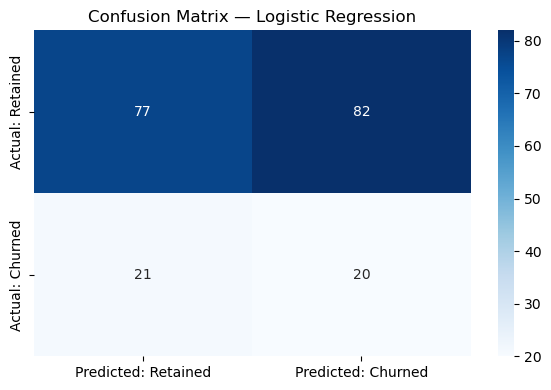

Saved as confusion_matrix.png


In [13]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted: Retained', 'Predicted: Churned'],
            yticklabels=['Actual: Retained', 'Actual: Churned'])
plt.title('Confusion Matrix — Logistic Regression')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()
print("Saved as confusion_matrix.png")

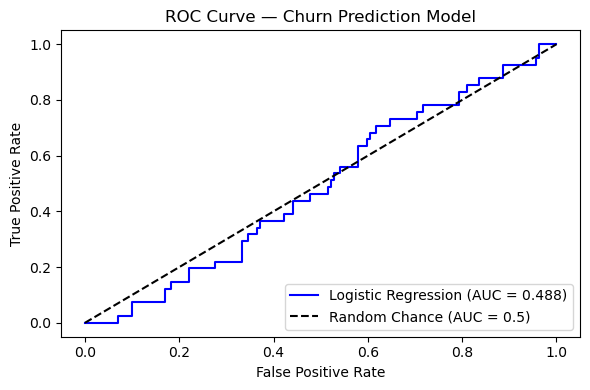

Saved as roc_curve.png


In [14]:
fpr, tpr, _ = roc_curve(y_test, y_proba)
auc_score   = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {auc_score:.3f})', color='blue')
plt.plot([0,1],[0,1], 'k--', label='Random Chance (AUC = 0.5)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Churn Prediction Model')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=150)
plt.show()
print("Saved as roc_curve.png")

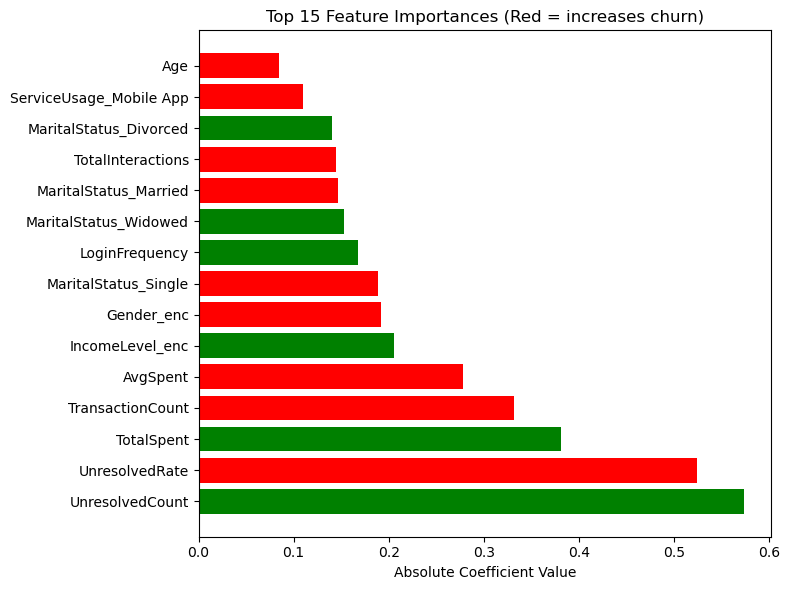

Saved as feature_importance.png


In [15]:
importance = pd.DataFrame({
    'Feature':     X.columns,
    'Coefficient': model.coef_[0]
}).reindex(pd.Series(model.coef_[0]).abs().sort_values(ascending=False).index)
importance = importance.head(15)

plt.figure(figsize=(8, 6))
colors = ['red' if c > 0 else 'green' for c in importance['Coefficient']]
plt.barh(importance['Feature'], importance['Coefficient'].abs(), color=colors)
plt.xlabel('Absolute Coefficient Value')
plt.title('Top 15 Feature Importances (Red = increases churn)')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()
print("Saved as feature_importance.png")

In [17]:
from IPython.display import FileLink
display(FileLink('confusion_matrix.png'))
display(FileLink('roc_curve.png'))
display(FileLink('feature_importance.png'))

C:\Users\Kirthi Sabari\predictive modelling\confusion_matrix.png

C:\Users\Kirthi Sabari\predictive modelling\roc_curve.png

C:\Users\Kirthi Sabari\predictive modelling\feature_importance.png